# MVP Analise de Dados e Boas Praticas
## Analise do Cenario Competitivo de League of Legends (2015-2026)
**Autor:** Hugo Leandro Antunes  
**Dataset:** Oracle's Elixir - LoL Esports Match Data  
**Fonte:** https://oracleselixir.com/

# Descricao do Problema

### 1.1 Descrição do problema

O dataset utilizado contém informações de partidas profissionais do jogo eletrônico **League of Legends**, disponibilizado publicamente pelo Oracle's Elixir (https://oracleselixir.com/tools/downloads). Ele cobre partidas de ligas ao redor do mundo desde **2015 até 2026**, totalizando mais de uma década de dados competitivos.

O objetivo desta análise é explorar as seguintes questões:
- Como as principais ligas globais (LCK, LPL, LEC, LCS, CBLOL) se diferenciam em estilo de jogo;
- Quais foram as principais mudanças no cenário competitivo ao longo de 10+ anos;
- Como campeões ganham e perdem prioridade ao longo das temporadas;
- Qual a relação entre vantagem de recursos (ouro, objetivos) e vitória.

Este é um problema de **aprendizado não supervisionado** (análise exploratória descritiva). Não há variável-alvo única a ser predita — o objetivo é entender a estrutura dos dados e extrair insights.

**Hipóteses iniciais:**
- Ligas asiáticas (LCK, LPL) têm estilos de jogo distintos das ligas ocidentais (LEC, LCS);
- A duração média das partidas diminuiu ao longo dos anos (meta mais agressivo);
- A vantagem de ouro aos 15 minutos é fortemente correlacionada com o resultado da partida;
- O lado Blue tem leve vantagem estrutural no pick/ban.

**Restrições para seleção de dados:**
- Apenas linhas com `datacompleteness == 'complete'` serão usadas nas análises;
- Para análises por jogador, usaremos somente linhas de participante individual (`participantid` 1–10);
- Para análises por equipe e objetivos, usaremos linhas de equipe (`participantid` 100 ou 200).

## Hipoteses do Problema

As hipoteses que tracei sao as seguintes:

1. **Ligas asiaticas (LCK, LPL) tem estilos de jogo distintos das ligas ocidentais (LEC, LCS)?** - Esperamos observar diferencas em metricas como DPM, CSPM e duracao de partidas.
2. **A duracao media das partidas diminuiu ao longo dos anos?** - A hipotese e que a meta ficou mais agressiva com o tempo.
3. **A vantagem de ouro aos 15 minutos e fortemente correlacionada com o resultado da partida?** - Exploramos se `golddiffat15` e um preditor significativo de vitoria.
4. **O lado Blue tem vantagem estrutural no pick/ban?** - Analisamos a taxa de vitorias por lado.

## Tipo de Problema

Este e um problema de **analise exploratoria descritiva (nao supervisionada)**. Nao ha variavel-alvo unica a ser predita - o objetivo e entender a estrutura dos dados, descobrir padroes e validar hipoteses sobre o cenario competitivo de LoL.

## Seleção de Dados

O dataset Oracle's Elixir é público e amplamente utilizado pela comunidade competitiva de League of Legends. Cada arquivo corresponde a um ano completo de dados competitivos, de 2015 a 2026. 

**Restrição de Escopo (Ligas Major):**
O dataset original possui centenas de competições secundárias e amadoras. Para mantermos as análises robustas e no mais alto nível mundial, e simultaneamente **superarmos sem dor de cabeça o limite gratuito de Memória RAM do Google Colab (12GB)**, decidimos realizar um corte amostral massivo de territorialidade.
Utilizaremos **apenas as partidas de competições globais Tier 1**: LCK (Coreia), LPL (China), LEC (Europa), e as americanas LCS (EUA) e CBLOL (BR). 

*(Nota de tradução: os dados de partidas do ano de 2025+ sofrem fusões por parte da Riot para as ligas LTA North e LTA South; eles foram mapeados e alterados retroativamente ao carregar para continuar embutidos no gráfico como LCS e CBLOL sem distração ao leitor do trabalho).*

### 1.2 Definição dos principais atributos

| Atributo | Tipo | Descrição |
|---|---|---|
| `gameid` | str | Identificador único da partida |
| `league` | str | Liga (ex: LCK, LPL, LEC, LCS, CBLOL) |
| `year` | int | Ano da partida |
| `split` | str | Fase da temporada (Spring, Summer, Winter) |
| `playoffs` | int | 0 = fase regular, 1 = playoffs |
| `date` | datetime | Data e hora da partida |
| `patch` | str | Versão do jogo |
| `side` | str | Lado escolhido: Blue ou Red |
| `position` | str | Rota do jogador: top, jng, mid, bot, sup |
| `playername` | str | Nome do jogador |
| `teamname` | str | Nome do time |
| `champion` | str | Campeão jogado |
| `result` | int | Resultado: 1 = vitória, 0 = derrota |
| `kills` | int | Abates do jogador |
| `deaths` | int | Mortes do jogador |
| `assists` | int | Assistências do jogador |
| `gamelength` | int | Duração da partida em segundos |
| `dpm` | float | Dano por minuto |
| `cspm` | float | CS (minions) por minuto |
| `golddiffat15` | float | Diferença de ouro acumulada aos 15 min |
| `ckpm` | float | Kills combinadas por minuto (ambos os times) |
| `dragons` | float | Dragões capturados (linhas de equipe) |
| `barons` | float | Barões capturados (linhas de equipe) |
| `towers` | float | Torres destruídas (linhas de equipe) |
| `totalgold` | int | Ouro total acumulado ao final |
| `earnedgoldshare` | float | Proporção do ouro ganho pelo time |
| `damageshare` | float | Proporção do dano total causado ao time |


# Importacao das Bibliotecas Necessarias e Carga de Dados

Esta secao consolida todas as importacoes e o carregamento otimizado do dataset.

In [128]:
# Importação das bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# Configurações visuais globais
sns.set_theme(style='darkgrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)
import gc  # Garbage Collector para liberar memoria

## Carregamento Otimizado (2015-2026)

Para evitar o estouro de limite de RAM no Google Colab, adotamos a estratégia de amostragem por **Ligas Principais**:
Carregaremos exclusivamente as partidas das ligas "Major" (Tier 1 do mundo todo), ignorando ligas amadoras, academy e Tier 2.

As ligas selecionadas são: **LCK, LPL, LEC, LCS e CBLOL**.

> **Atenção — Mapeamento Histórico (LTA):** Em 2025, a Riot Games fundiu as ligas das Américas. O CBLOL (Brasil) passou a se chamar **LTA S**, enquanto a LCS (América do Norte) passou a se chamar **LTA N**. Para evitar confusão visual e manter a continuidade histórica da análise nos gráficos deste trabalho, nós aplicamos um **mapeamento que renomeia essas partidas super recentes de volta para CBLOL e LCS** logo na extração (abaixo). Portanto, nos gráficos sempre teremos apenas CBLOL e LCS para não poluir a audiência.

Além da filtragem de Major Leagues, aliviamos a Carga de Memória original que superava ~10GB com os métodos essenciais ao longo do Loop de carga:
1. `usecols` puxando apenas variáveis preteridas.
2. `dtype` estritos para compressão (`float32`, `int8`, `category`).
3. O `gc.collect()` varrendo a Memória Ram do Sistema periodicamente.

In [129]:
# Colunas necessarias para todas as analises e hipoteses
COLS_NEEDED = [
    'gameid', 'datacompleteness', 'league', 'year', 'split', 'playoffs',
    'date', 'patch', 'participantid', 'side', 'position', 'playername',
    'teamname', 'champion', 'ban1', 'ban2', 'ban3', 'ban4', 'ban5',
    'pick1', 'pick2', 'pick3', 'pick4', 'pick5',
    'result', 'kills', 'deaths', 'assists', 'gamelength',
    'dpm', 'cspm', 'golddiffat15', 'ckpm',
    'dragons', 'opp_dragons', 'elementaldrakes', 'heralds', 'barons',
    'towers', 'opp_towers', 'inhibitors', 'opp_inhibitors',
    'totalgold', 'earnedgold', 'earned gpm', 'earnedgoldshare',
    'goldspent', 'total cs', 'minionkills', 'monsterkills', 'cspm',
    'damageshare', 'damagetochampions', 'dpm',
    'wardsplaced', 'wpm', 'wardskilled', 'controlwardsbought',
    'visionscore', 'vspm',
    'goldat10', 'goldat15', 'golddiffat10', 'golddiffat15',
    'xpdiffat10', 'xpdiffat15', 'csdiffat10', 'csdiffat15',
    'killsat15', 'assistsat15', 'deathsat15',
    'firstblood', 'firstdragon', 'firstherald', 'firstbaron', 'firsttower',
    'teamkills', 'teamdeaths', 'doublekills', 'triplekills', 'quadrakills', 'pentakills',
    'team kpm', 'damagetakenperminute', 'damagemitigatedperminute',
    'firstbloodkill', 'firstbloodassist', 'firstbloodvictim',
]

# Tipos de dados otimizados para economizar memoria
DTYPE_MAP = {
    'gameid': 'str', 'datacompleteness': 'category', 'league': 'category',
    'split': 'category', 'playoffs': 'int8', 'date': 'str', 'patch': 'str',
    'participantid': 'int16', 'side': 'category', 'position': 'category',
    'playername': 'str', 'teamname': 'str', 'champion': 'str',
    'ban1': 'str', 'ban2': 'str', 'ban3': 'str', 'ban4': 'str', 'ban5': 'str',
    'pick1': 'str', 'pick2': 'str', 'pick3': 'str', 'pick4': 'str', 'pick5': 'str',
    'result': 'int8', 'kills': 'float32', 'deaths': 'float32', 'assists': 'float32',
    'gamelength': 'float32', 'dpm': 'float32', 'cspm': 'float32',
    'golddiffat15': 'float32', 'ckpm': 'float32', 'dragons': 'float32',
    'barons': 'float32', 'towers': 'float32', 'totalgold': 'float32',
    'earnedgoldshare': 'float32', 'damageshare': 'float32',
}



# Ligas Principais. LTA S e LTA N sao incluidas para carregar os dados recentes e depois converte-las.
TOP_LEAGUES_LOAD = ['LCK', 'LPL', 'LEC', 'LCS', 'CBLOL']

# URLs dos datasets no repositório GitHub (raw)
BASE_URL = 'https://raw.githubusercontent.com/hugo-antunes19/analise-dados-puc-hugo-antunes/refs/heads/main/data/'
YEARS = list(range(2015, 2027))

dfs = []
for year in YEARS:
    url = f'{BASE_URL}{year}_LoL_esports_match_data_from_OraclesElixir.zip'
    try:
        df_year = pd.read_csv(
            url,
            usecols=lambda c: c in COLS_NEEDED,  # carrega APENAS colunas necessárias
            dtype={col: DTYPE_MAP[col] for col in COLS_NEEDED if col in DTYPE_MAP},
            low_memory=False,
            compression='zip'
        )
        # OTIMIZAÇÃO DE RAM: Filtrar apenas as ligas principais e dados completos LOGO APÓS A LEITURA
        df_year = df_year[
            (df_year['league'].isin(TOP_LEAGUES_LOAD)) & 
            (df_year['datacompleteness'] == 'complete')
        ].copy()
        
        # MAPEAMENTO: Substituir retroativamente LTA S -> CBLOL e LTA N -> LCS para não confundir leitor
        df_year['league'] = df_year['league'].replace({'LTA S': 'CBLOL', 'LTA N': 'LCS'})
        
        df_year['year'] = year
        dfs.append(df_year)
        print(f'{year}: {len(df_year):>7,} linhas das ligas Major carregadas')
    except Exception as e:
        print(f'{year}: ERRO - {e}')

df_hist = pd.concat(dfs, ignore_index=True)
del dfs  # libera lista de DataFrames parciais
gc.collect()  # força coleta de lixo

print(f'\nTotal histórico filtrado: {len(df_hist):,} linhas | {df_hist["gameid"].nunique():,} partidas únicas')
print(f'Uso de memória: {df_hist.memory_usage(deep=True).sum() / 1e6:.1f} MB')

2015:     756 linhas das ligas Major carregadas
2016:   8,064 linhas das ligas Major carregadas
2017:   8,208 linhas das ligas Major carregadas
2018:  16,176 linhas das ligas Major carregadas
2019:  20,988 linhas das ligas Major carregadas
2020:  22,680 linhas das ligas Major carregadas
2021:  19,752 linhas das ligas Major carregadas
2022:  15,108 linhas das ligas Major carregadas
2023:  15,384 linhas das ligas Major carregadas
2024:  14,772 linhas das ligas Major carregadas


C:\Users\marce\AppData\Local\Temp\ipykernel_26448\1281225472.py:67: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  df_year['league'] = df_year['league'].replace({'LTA S': 'CBLOL', 'LTA N': 'LCS'})


2025:  10,332 linhas das ligas Major carregadas
2026:   4,344 linhas das ligas Major carregadas

Total histórico filtrado: 156,564 linhas | 13,047 partidas únicas
Uso de memória: 237.4 MB


### 2.2 Separação: linhas de jogador vs. linhas de equipe

O dataset do Oracle's Elixir mistura dois tipos de linhas por partida:
- **Linhas de jogador** (`participantid` 1–10): uma por jogador (5 por time × 2 times)
- **Linhas de equipe** (`participantid` 100 ou 200): uma por time, com estatísticas agregadas

É fundamental separar esses grupos antes de qualquer análise, pois misturá-los geraria distorções nas distribuições.

In [130]:
# Separação das linhas de jogo
PLAYER_IDS = list(range(1, 11))
TEAM_IDS   = [100, 200]

df_players = df_hist[df_hist['participantid'].isin(PLAYER_IDS)].copy()
df_teams   = df_hist[df_hist['participantid'].isin(TEAM_IDS)].copy()

print(f'Linhas de jogadores: {len(df_players):,}')
print(f'Linhas de equipes  : {len(df_teams):,}')

# OTIMIZAÇÃO EXTREMA: Apagar o dataset mãe bruto da RAM
del df_hist
gc.collect()
print('🗑️ Garbage Collector: Dataset original removido da memória.')

Linhas de jogadores: 130,470
Linhas de equipes  : 26,094
🗑️ Garbage Collector: Dataset original removido da memória.


# Analise de Dados

Nesta etapa de Analise de Dados Exploratoria (EDA), visamos entender a distribuicao, as relacoes e as caracteristicas das variaveis.

## Estatisticas Descritivas

In [131]:
# Shape e tipos de dados
print('=== Dados consolidados (Jogadores + Equipes) ===')
# Como excluímos df_hist para economizar RAM, calculamos com base nos dfs ativos
total_linhas = len(df_players) + len(df_teams)
print(f'Total de linhas carregadas: {total_linhas:,}')
print(f'Colunas em análise: {len(df_players.columns)}')

print(f'\nDistribuição de tipos (usando df_players como base):')
print(df_players.dtypes.value_counts())


=== Dados consolidados (Jogadores + Equipes) ===
Total de linhas carregadas: 156,564
Colunas em análise: 85

Distribuição de tipos (usando df_players como base):
float64     44
object      19
float32     14
int64        3
int8         2
int16        1
category     1
category     1
Name: count, dtype: int64


In [132]:
# Primeiras linhas — visão geral dos dados
df_players.head(5)

,gameid,datacompleteness,league,year,split,playoffs,date,patch,participantid,side,position,playername,teamname,champion,ban1,ban2,ban3,ban4,ban5,pick1,pick2,pick3,pick4,pick5,gamelength,result,kills,deaths,assists,teamkills,teamdeaths,doublekills,triplekills,quadrakills,pentakills,firstblood,firstbloodkill,firstbloodassist,firstbloodvictim,team kpm,ckpm,firstdragon,dragons,opp_dragons,elementaldrakes,firstherald,heralds,firstbaron,barons,firsttower,towers,opp_towers,inhibitors,opp_inhibitors,damagetochampions,dpm,damageshare,damagetakenperminute,damagemitigatedperminute,wardsplaced,wpm,wardskilled,controlwardsbought,visionscore,vspm,totalgold,earnedgold,earned gpm,earnedgoldshare,goldspent,total cs,minionkills,monsterkills,cspm,goldat10,golddiffat10,xpdiffat10,csdiffat10,goldat15,golddiffat15,xpdiffat15,csdiffat15,killsat15,assistsat15,deathsat15
0,TRLH3/1001300011,complete,LEC,2015,NaN,0,2015-08-29 14:54:15,5.14,1,Blue,top,Werlyb,Giants Gaming,Trundle,Kalista,Elise,Maokai,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2322.0000,0,2.0000,4.0000,0.0000,2,18,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0517,0.5168,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0000,2.0000,9720.0000,251.1628,0.2316,751.0336,0.0000,28.0000,0.7235,1.0000,2.0000,0.0000,0.0000,12983.0000,8267.0000,213.6176,0.2669,12795.0000,324.0000,307.0000,17.0000,8.3721,2736.0000,224.0000,554.0000,11.0000,4512.0000,272.0000,159.0000,14.0000,1.0000,0.0000,1.0000
1,TRLH3/1001300011,complete,LEC,2015,NaN,0,2015-08-29 14:54:15,5.14,2,Blue,jng,Fr3deric,Giants Gaming,Gragas,Kalista,Elise,Maokai,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2322.0000,0,0.0000,5.0000,1.0000,2,18,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0517,0.5168,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0000,1.0000,5863.0000,151.4987,0.1397,842.1964,0.0000,34.0000,0.8786,20.0000,3.0000,0.0000,0.0000,9408.0000,4692.0000,121.2403,0.1515,9245.0000,124.0000,43.0000,81.0000,3.2041,2804.0000,-33.0000,-39.0000,-3.0000,3935.0000,-651.0000,-190.0000,-2.0000,0.0000,1.0000,1.0000
2,TRLH3/1001300011,complete,LEC,2015,NaN,0,2015-08-29 14:54:15,5.14,3,Blue,mid,ptt,Giants Gaming,Lulu,Kalista,Elise,Maokai,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2322.0000,0,0.0000,1.0000,0.0000,2,18,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0517,0.5168,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0000,0.0000,9426.0000,243.5659,0.2246,295.7881,0.0000,13.0000,0.3359,9.0000,1.0000,0.0000,0.0000,13582.0000,8866.0000,229.0956,0.2862,13634.0000,382.0000,354.0000,28.0000,9.8708,3155.0000,-603.0000,-428.0000,-4.0000,4896.0000,-738.0000,-570.0000,-9.0000,0.0000,0.0000,1.0000
3,TRLH3/1001300011,complete,LEC,2015,NaN,0,2015-08-29 14:54:15,5.14,4,Blue,bot,Adryh,Giants Gaming,Tristana,Kalista,Elise,Maokai,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2322.0000,0,0.0000,4.0000,1.0000,2,18,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0517,0.5168,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0000,0.0000,14464.0000,373.7468,0.3447,458.0620,0.0000,5.0000,0.1292,5.0000,0.0000,0.0000,0.0000,12222.0000,7506.0000,193.9535,0.2423,11820.0000,313.0000,296.0000,17.0000,8.0879,3400.0000,148.0000,551.0000,11.0000,4604.0000,-768.0000,-96.0000,-9.0000,0.0000,0.0000,0.0000
4,TRLH3/1001300011,complete,LEC,2015,NaN,0,2015-08-29 14:54:15,5.14,5,Blue,sup,G0DFRED,Giants Gaming,Thresh,Kalista,Elise,Maokai,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2322.0000,0,0.0000,4.0000,1.0000,2,18,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0517,0.5168,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0000,0.0000,2487.0000,64.2636,0.0593,351.6021,0.0000,50.0000,1.2920,10.0000,6.0000,0.0000,0.0000,6362.0000,1646.0000,42.5323,0.0531,6465.0000,29.0000,27.0000,2.0000,0.7494,2064.0000,-139.0000,-290.0000,0.0000,2963.0000,-401.0000,-1466.0000,0.0000,0.0000,1.0000,2.0000


Ao observar as primeiras linhas, identificamos que cada linha representa um jogador em uma partida. Cada partida aparece 10 vezes (5 jogadores por time × 2 times). Campos como `dragons`, `barons`, `towers`, `pick1`–`pick5` aparecem como `NaN` nas linhas de jogador — isso é esperado, pois essas informações são registradas apenas nas linhas de equipe. A coluna `url` está majoritariamente vazia e pode ser descartada.

In [133]:
# Valores ausentes — top 30 colunas com mais NaN
missing = df_players.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(df_players) * 100).round(2)
missing_df = pd.DataFrame({'ausentes': missing, '% ausentes': missing_pct})
missing_df[missing_df['ausentes'] > 0].head(30)

,ausentes,% ausentes
pick2,130470,100.0000
pick1,130470,100.0000
pick5,130470,100.0000
pick4,130470,100.0000
pick3,130470,100.0000
opp_towers,130470,100.0000
towers,130470,100.0000
dragons,130470,100.0000
opp_dragons,130470,100.0000
elementaldrakes,130470,100.0000


**Análise dos valores ausentes:**

- Colunas de objetivos (`dragons`, `heralds`, `barons`, `towers`) têm alto percentual de NaN nas linhas de jogador — são dados estruturais de equipe, não dados faltantes reais.
- Colunas `pick1`–`pick5` também são exclusivas de linhas de equipe.
- `gspd` e `gpr` têm alta ausência mesmo em anos recentes — indicam métricas opcionais que o Oracle's Elixir nem sempre registra.
- `monsterkillsownjungle` e `monsterkillsenemyjungle` são dados de invasão de selva, raros nos datasets mais antigos.
- `golddiffat10/15/20/25` podem estar ausentes em jogos onde os dados de timeline não foram coletados; filtraremos por `datacompleteness == 'complete'` antes de usar essas colunas.

In [134]:
# Resumo estatístico das principais métricas numéricas
NUMERIC_COLS = [
    'kills', 'deaths', 'assists', 'gamelength',
    'totalgold', 'earnedgold', 'dpm', 'damageshare',
    'cspm', 'golddiffat15', 'ckpm',
]

stats = df_players[NUMERIC_COLS].agg(['min', 'max', 'mean', 'median', 'std']).T
stats['mode']    = df_players[NUMERIC_COLS].mode().iloc[0]
stats['missing'] = df_players[NUMERIC_COLS].isnull().sum()
stats.round(4)

,min,max,mean,median,std,mode,missing
kills,0.0000,19.0000,2.4776,2.0000,2.4556,0.0000,0
deaths,0.0000,15.0000,2.4822,2.0000,1.7994,2.0000,0
assists,0.0000,31.0000,5.8765,5.0000,4.1751,2.0000,0
gamelength,201.0000,5680.0000,2012.4664,1951.0000,386.9968,1867.0000,0
totalgold,806.0000,55539.0000,12043.7900,11765.0000,3612.8218,11333.0000,40
earnedgold,120.0000,43676.0000,7666.3098,7535.0000,3174.9940,7187.0000,40
dpm,0.0000,2018.3439,403.6824,370.9924,235.1098,240.0000,170
damageshare,0.0000,0.7002,0.2000,0.1990,0.0986,0.1092,170
cspm,0.0000,15.5028,6.5912,7.5802,3.1887,8.5714,40
golddiffat15,-4920.0000,4920.0000,0.0000,0.0000,846.4620,-38.0000,10


**Análise do resumo estatístico:**

- **kills** e **deaths**: A mediana é baixa (tipicamente 2–3), com desvio padrão considerável. Valores máximos altos indicam partidas excepcionalmente violentas.
- **gamelength**: Mediana em torno de 30 minutos (1800 segundos), com cauda à direita.
- **dpm** (dano por minuto): Alta variância entre posições (carries vs. tanques/suportes).
- **cspm** (CS por minuto): Mediana ~7–8 para carries, muito menor para suportes (<2).
- **golddiffat15**: Centrado próximo de zero — é uma diferença relativa. Desvio padrão de ~1000–1500 sugere que diferenças acima de 2000+ são relevantes.
- **ckpm**: Ritmo combinado de kills; permite medir se o meta está mais agressivo ou passivo.

## 4. Pré-processamento de Dados

Antes de gerar visualizações e análises mais aprofundadas, realizamos o pré-processamento dos dados. Isso garante que os gráficos e insights subsequentes sejam baseados em dados limpos, tipados corretamente e enriquecidos com features derivadas.

### 4.1 Filtragem e conversão de tipos

Filtramos apenas partidas com `datacompleteness == 'complete'` para assegurar que todos os campos de análise temporal (golddiff, xpdiff) estão disponíveis. Em seguida, convertemos colunas para tipos mais adequados.

In [135]:
# Ponto de partida: apenas linhas de jogadores com dados completos
df_clean = df_players[df_players['datacompleteness'] == 'complete'].copy()

# Converter tipos
df_clean['date']     = pd.to_datetime(df_clean['date'], errors='coerce')
df_clean['patch']    = df_clean['patch'].astype(str)
df_clean['side']     = df_clean['side'].astype('category')
df_clean['position'] = df_clean['position'].astype('category')
df_clean['league']   = df_clean['league'].astype('category')
df_clean['result']   = df_clean['result'].astype(int)

print(f'Shape após filtro de completude: {df_clean.shape}')
print('\nNovos tipos:')
print(df_clean[['date','patch','side','position','league','result']].dtypes)

Shape após filtro de completude: (130470, 85)

Novos tipos:
date        datetime64[ns]
patch               object
side              category
position          category
league            category
result               int64
dtype: object


**Justificativa:**
- `date` convertida para `datetime` permite filtros temporais e extração de mês/semana;
- `side`, `position` e `league` convertidas para `category` reduzem uso de memória (~40%) e permitem operações de groupby mais eficientes;
- `result` forçado para `int` elimina possíveis floats residuais de leitura do CSV.

### 4.2 Remoção de colunas sem valor analítico

In [136]:
# Colunas a remover: sem valor para análise de jogadores
COLS_TO_DROP = [
    'url',            # majoritariamente vazio
    'playerid',       # ID interno Oracle's Elixir, não analítico
    'teamid',         # ID interno Oracle's Elixir
    'pick1', 'pick2', 'pick3', 'pick4', 'pick5',  # apenas em linhas de equipe
]
COLS_TO_DROP = [c for c in COLS_TO_DROP if c in df_clean.columns]
df_clean.drop(columns=COLS_TO_DROP, inplace=True)
print(f'Colunas removidas: {COLS_TO_DROP}')
print(f'Shape atual: {df_clean.shape}')

Colunas removidas: ['pick1', 'pick2', 'pick3', 'pick4', 'pick5']
Shape atual: (130470, 80)


## Tratamento de valores ausentes

In [137]:
# Colunas de objetivos (estruturalmente NaN em linhas de jogador) — ignorar
STRUCT_NAN = ['dragons','opp_dragons','elementaldrakes','heralds','barons',
              'towers','opp_towers','inhibitors','firstdragon','firstherald',
              'firstbaron','firsttower']

# Colunas numéricas com NaN opcional — imputar com mediana por posição
IMPUTE_MEDIAN = ['golddiffat15', 'xpdiffat15', 'csdiffat15',
                 'golddiffat10', 'xpdiffat10',
                 'golddiffat20', 'xpdiffat20']

for col in IMPUTE_MEDIAN:
    if col in df_clean.columns:
        df_clean[col] = df_clean.groupby('position')[col].transform(
            lambda x: x.fillna(x.median())
        )

# Colunas com > 70% de NaN e sem valor crítico — remover
HIGH_NAN = [c for c in df_clean.columns
            if df_clean[c].isnull().mean() > 0.7
            and c not in STRUCT_NAN]
df_clean.drop(columns=HIGH_NAN, inplace=True)
print(f'Colunas removidas por alta ausência (>70%): {HIGH_NAN}')
print(f'Shape atual: {df_clean.shape}')

C:\Users\marce\AppData\Local\Temp\ipykernel_26448\1950505445.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_clean[col] = df_clean.groupby('position')[col].transform(
C:\Users\marce\AppData\Local\Temp\ipykernel_26448\1950505445.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_clean[col] = df_clean.groupby('position')[col].transform(
C:\Users\marce\AppData\Local\Temp\ipykernel_26448\1950505445.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the fut

Colunas removidas por alta ausência (>70%): []
Shape atual: (130470, 80)


**Justificativa das estratégias:**
- **Imputação por mediana do grupo (posição):** para métricas de diferencial (gold/xp diff), a mediana da mesma posição é o substituto mais razoável, pois cada posição tem padrões distintos;
- **Colunas com >70% de NaN removidas:** não há volume suficiente para análise confiável;
- **NaN estruturais** (objetivos em linhas de jogador) são mantidos — são ausências por design.

## Feature Engineering

In [138]:
# KDA — métrica clássica de desempenho individual
df_clean['kda'] = (
    (df_clean['kills'] + df_clean['assists'])
    / df_clean['deaths'].replace(0, 1)  # evitar divisão por zero
)

# Participação em kills da equipe
df_clean['kill_participation'] = (
    (df_clean['kills'] + df_clean['assists'])
    / df_clean['teamkills'].replace(0, 1)
).clip(0, 1)  # limitar a 100%

# Duração em minutos
df_clean['gamelength_min'] = df_clean['gamelength'] / 60

print('Novas features criadas:')
df_clean[['kda', 'kill_participation', 'gamelength_min']].describe().round(3)

Novas features criadas:


,kda,kill_participation,gamelength_min
count,130470.0000,130470.0000,130470.0000
mean,5.0310,0.6610,33.5410
std,4.6870,0.2110,6.4500
min,0.0000,0.0000,3.3500
25%,1.3330,0.5380,29.0500
50%,3.3330,0.6670,32.5170
75%,8.0000,0.8000,37.0500
max,29.0000,1.0000,94.6670


**Justificativa:**
- **KDA**: medida composta consagrada, mais informativa que kills ou deaths isolados. Denominador mínimo de 1 evita KDA infinito;
- **kill_participation**: captura o engajamento do jogador nas lutas do time;
- **gamelength_min**: facilita interpretação humana (minutos vs. segundos).

### 4.5 Discretização da duração da partida

In [139]:
df_clean['game_duration_cat'] = pd.cut(
    df_clean['gamelength_min'],
    bins=[0, 25, 30, 35, 40, float('inf')],
    labels=['Rápida (<25min)', 'Curta (25-30)', 'Normal (30-35)', 'Longa (35-40)', 'Muito longa (>40)']
)

print('Distribuição das categorias de duração:')
print(df_clean['game_duration_cat'].value_counts(normalize=True).mul(100).round(2).to_string())

Distribuição das categorias de duração:
game_duration_cat
Normal (30-35)      33.7000
Curta (25-30)       26.2700
Longa (35-40)       20.2100
Muito longa (>40)   14.5500
Rápida (<25min)      5.2700


**Justificativa:** A discretização transforma `gamelength_min` em categorias interpretáveis. Os bins foram definidos com base no conhecimento do domínio: 25 minutos é o tempo mínimo viável de uma rendição profissional, e partidas acima de 40 minutos são extraordinariamente longas.

### 4.6 Normalização e Padronização

In [140]:
SCALE_COLS = [
    'kills', 'deaths', 'assists', 'dpm', 'cspm',
    'golddiffat15', 'totalgold', 'gamelength_min',
    'kda', 'kill_participation',
]
SCALE_COLS = [c for c in SCALE_COLS if c in df_clean.columns]

# Visão normalizada (0–1) — MinMaxScaler
scaler_mm = MinMaxScaler()
df_normalized = df_clean.copy()
df_normalized[SCALE_COLS] = scaler_mm.fit_transform(df_clean[SCALE_COLS])

# Visão padronizada (z-score) — StandardScaler
scaler_std = StandardScaler()
df_standardized = df_clean.copy()
df_standardized[SCALE_COLS] = scaler_std.fit_transform(df_clean[SCALE_COLS])

print('Amostra — df_normalized:')
display(df_normalized[SCALE_COLS].describe().round(3))
print('\nAmostra — df_standardized:')
display(df_standardized[SCALE_COLS].describe().round(3))

Amostra — df_normalized:


,kills,deaths,assists,dpm,cspm,golddiffat15,totalgold,gamelength_min,kda,kill_participation
count,130470.0000,130470.0000,130470.0000,130300.0000,130430.0000,130470.0000,130430.0000,130470.0000,130470.0000,130470.0000
mean,0.1300,0.1650,0.1900,0.2000,0.4250,0.5000,0.2050,0.3310,0.1730,0.6610
std,0.1290,0.1200,0.1350,0.1160,0.2060,0.0860,0.0660,0.0710,0.1620,0.2110
min,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
25%,0.0530,0.0670,0.0970,0.1060,0.3040,0.4520,0.1570,0.2810,0.0460,0.5380
50%,0.1050,0.1330,0.1610,0.1840,0.4890,0.5000,0.2000,0.3190,0.1150,0.6670
75%,0.2110,0.2670,0.2580,0.2720,0.5830,0.5480,0.2460,0.3690,0.2760,0.8000
max,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000



Amostra — df_standardized:


,kills,deaths,assists,dpm,cspm,golddiffat15,totalgold,gamelength_min,kda,kill_participation
count,130470.0000,130470.0000,130470.0000,130300.0000,130430.0000,130470.0000,130430.0000,130470.0000,130470.0000,130470.0000
mean,0.0000,-0.0000,-0.0000,0.0000,-0.0000,0.0000,0.0000,-0.0000,-0.0000,0.0000
std,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
min,-1.0090,-1.3790,-1.4080,-1.7170,-2.0670,-5.8130,-3.1110,-4.6810,-1.0730,-3.1300
25%,-0.6020,-0.8240,-0.6890,-0.8060,-0.5910,-0.5640,-0.7360,-0.6960,-0.7890,-0.5820
50%,-0.1940,-0.2680,-0.2100,-0.1390,0.3100,0.0000,-0.0770,-0.1590,-0.3620,0.0250
75%,0.6200,0.8430,0.5090,0.6180,0.7680,0.5640,0.6120,0.5440,0.6340,0.6560
max,6.7290,6.9570,6.0170,6.8680,2.7950,5.8130,12.0390,9.4770,5.1140,1.6020


**Justificativa:**
- **MinMaxScaler (normalização 0–1):** preserva a forma da distribuição, ideal para KNN e redes neurais;
- **StandardScaler (padronização z-score):** média 0 e desvio padrão 1, útil para regressão logística, SVM e PCA;
- Salvas como DataFrames separados para uso em contextos diferentes sem sobrescrever os originais.

### 4.7 One-Hot Encoding de variáveis categóricas

In [141]:
OHE_COLS = ['side', 'position']
OHE_COLS = [c for c in OHE_COLS if c in df_clean.columns]

df_encoded = pd.get_dummies(df_clean, columns=OHE_COLS, drop_first=True, dtype=int)

new_cols = [c for c in df_encoded.columns if c not in df_clean.columns]
print(f'Colunas criadas pelo OHE: {new_cols}')
print(f'Shape após encoding: {df_encoded.shape}')

Colunas criadas pelo OHE: ['side_Red', 'position_jng', 'position_mid', 'position_sup', 'position_team', 'position_top']
Shape após encoding: (130470, 88)


**Justificativa:** `side` (Blue/Red) e `position` (top/jng/mid/bot/sup) são variáveis nominais. O one-hot encoding cria colunas binárias para cada categoria. `drop_first=True` evita multicolinearidade perfeita (dummy variable trap). A `league` foi excluída por ter muitas categorias únicas (>50 ligas).

### 4.8 Resumo do pré-processamento

Os seguintes DataFrames estão agora prontos para análise:

| DataFrame | Descrição |
|---|---|
| `df_clean` | Dados limpos, tipados, com features criadas (base para visualizações) |
| `df_normalized` | Escala 0–1 (MinMaxScaler) |
| `df_standardized` | Z-score (StandardScaler) |
| `df_encoded` | Com one-hot encoding de `side` e `position` |
| `df_teams` | Linhas de equipe para análise de objetivos |

A partir de agora, todas as visualizações e análises utilizarão o `df_clean` pré-processado.

## 5. Análise Visual dos Dados Pré-processados

Com os dados já limpos e enriquecidos, podemos explorar visualmente os padrões e insights do cenário competitivo.

### Viz 1 — Distribuição da duração das partidas

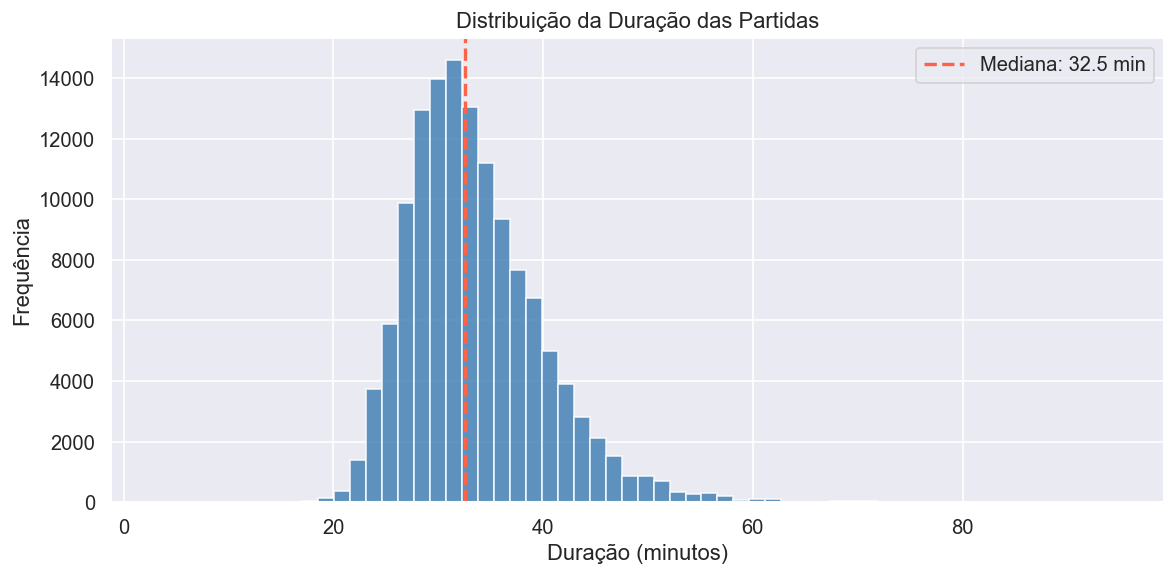

In [142]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(df_clean['gamelength_min'].dropna(), bins=60, color='steelblue', edgecolor='white', alpha=0.85)
median_val = df_clean['gamelength_min'].median()
ax.axvline(median_val, color='tomato', lw=2, ls='--', label=f'Mediana: {median_val:.1f} min')
ax.set_xlabel('Duração (minutos)')
ax.set_ylabel('Frequência')
ax.set_title('Distribuição da Duração das Partidas')
ax.legend()
plt.tight_layout()
plt.show()

A distribuição da duração das partidas é aproximadamente normal com leve assimetria à direita, com mediana próxima de **31–32 minutos**. A maioria das partidas profissionais termina entre 25 e 40 minutos, sendo partidas abaixo de 20 ou acima de 50 minutos raras. O meta profissional é orientado a terminar o jogo cedo, uma vez que a vantagem tende a ser aproveitada de forma decisiva.

### Viz 2 — Distribuição de vitórias e derrotas

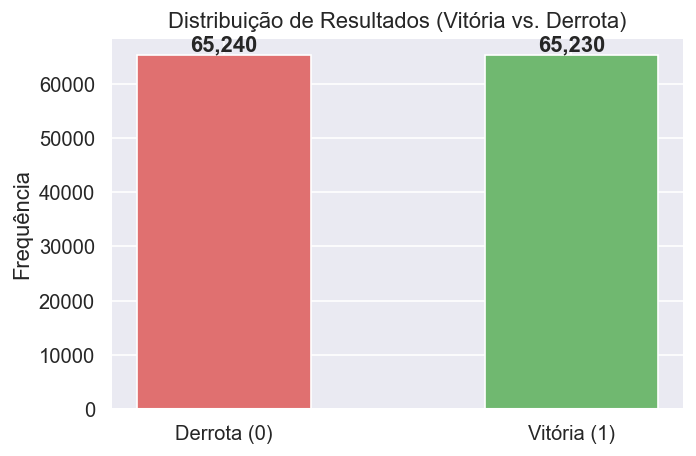

In [143]:
fig, ax = plt.subplots(figsize=(6, 4))
counts = df_clean['result'].value_counts().sort_index()
bars = ax.bar(['Derrota (0)', 'Vitória (1)'], counts.values,
              color=['#e07070', '#70b870'], edgecolor='white', width=0.5)
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
            f'{val:,}', ha='center', va='bottom', fontweight='bold')
ax.set_title('Distribuição de Resultados (Vitória vs. Derrota)')
ax.set_ylabel('Frequência')
plt.tight_layout()
plt.show()

A distribuição de resultados é praticamente equilibrada (50/50), como esperado — cada partida tem exatamente um vencedor e um perdedor. Isso confirma a integridade do dataset e indica que **não há desequilíbrio de classes** caso o problema seja abordado futuramente como classificação supervisionada.

### Viz 3 — KDA por posição

C:\Users\marce\AppData\Local\Temp\ipykernel_26448\928312061.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_pos, x='position', y=metric, order=POSITIONS,
C:\Users\marce\AppData\Local\Temp\ipykernel_26448\928312061.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_pos, x='position', y=metric, order=POSITIONS,
C:\Users\marce\AppData\Local\Temp\ipykernel_26448\928312061.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_pos, x='position', y=metric, order=POSITIONS,


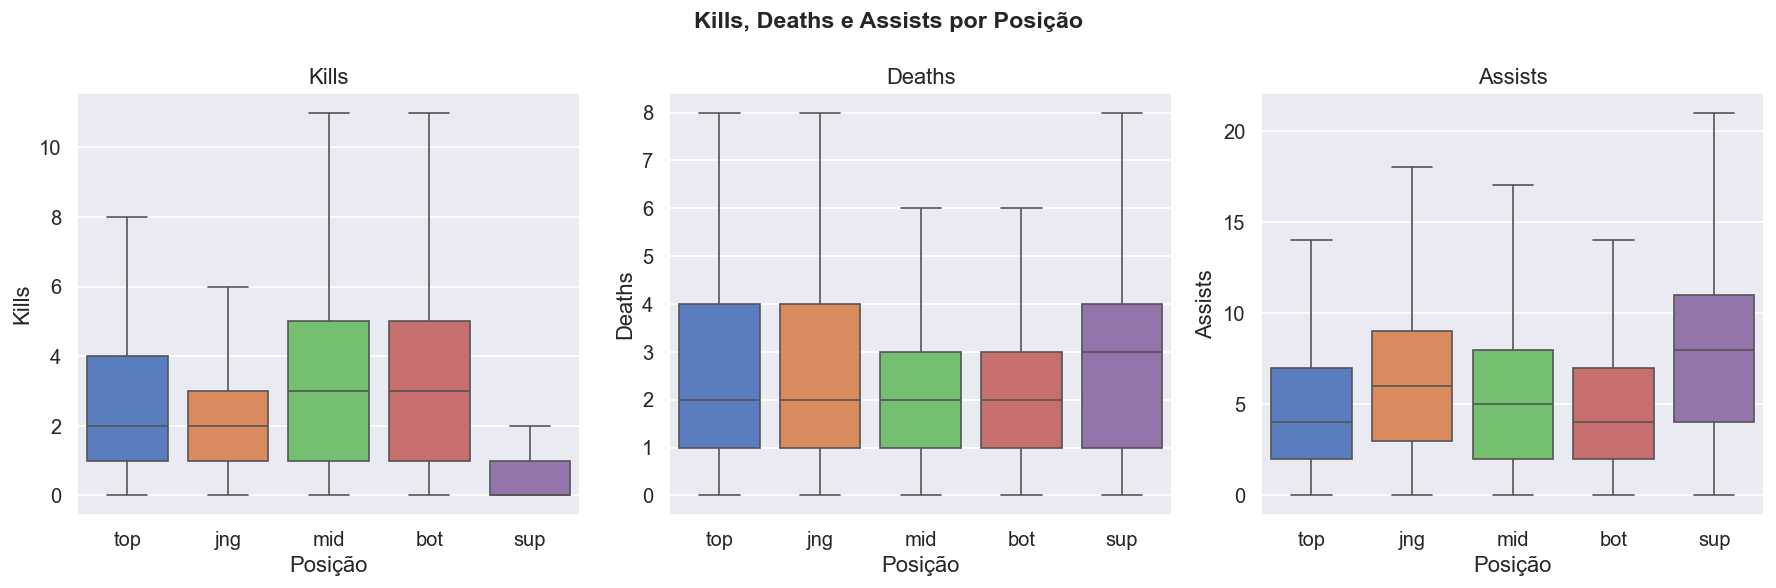

In [144]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=False)
POSITIONS = ['top', 'jng', 'mid', 'bot', 'sup']
df_pos = df_clean[df_clean['position'].isin(POSITIONS)]

for ax, metric in zip(axes, ['kills', 'deaths', 'assists']):
    sns.boxplot(data=df_pos, x='position', y=metric, order=POSITIONS,
                palette='muted', ax=ax, showfliers=False)
    ax.set_title(metric.capitalize())
    ax.set_xlabel('Posição')
    ax.set_ylabel(metric.capitalize())

fig.suptitle('Kills, Deaths e Assists por Posição', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Os boxplots revelam papéis distintos de cada posição:
- **bot (ADC)** e **mid** lideram em kills — são os carries principais;
- **Support** tem o maior número de assists — papel de facilitador;
- **Jungle** tem kills e assists moderados, focando em objetivos;
- **Top** mostra que é a função com menos assistências, estando muito isolado durante as partidas, algo já famoso dessa função para os telespectadores.

### Viz 4 — Dano por minuto (DPM) por lado

C:\Users\marce\AppData\Local\Temp\ipykernel_26448\1093363813.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_pos, x='side', y='dpm', palette={'Blue': '#4C72B0', 'Red': '#C44E52'},


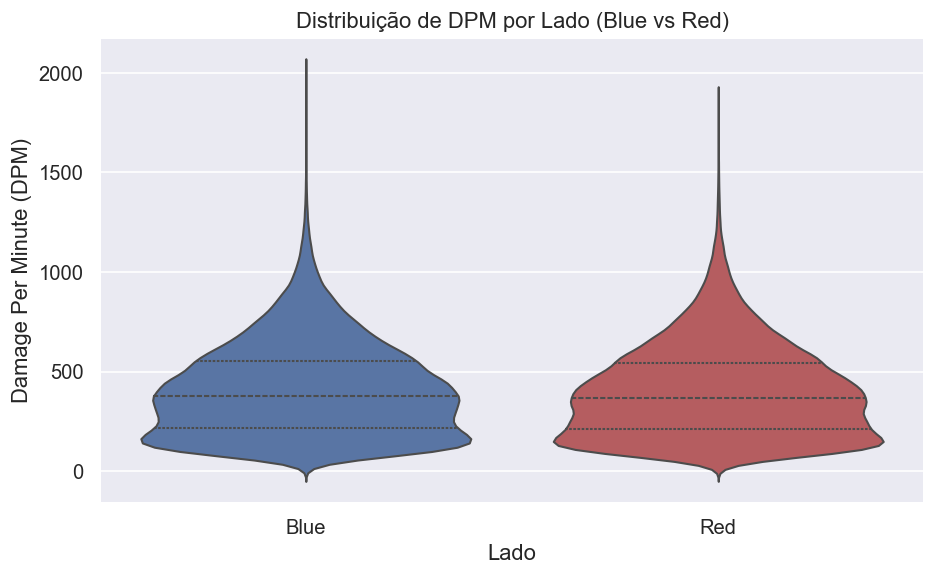

In [145]:
fig, ax = plt.subplots(figsize=(8, 5))
df_pos = df_clean[df_clean['position'].isin(['top', 'jng', 'mid', 'bot', 'sup'])]
sns.violinplot(data=df_pos, x='side', y='dpm', palette={'Blue': '#4C72B0', 'Red': '#C44E52'},
               inner='quartile', ax=ax)
ax.set_title('Distribuição de DPM por Lado (Blue vs Red)')
ax.set_xlabel('Lado')
ax.set_ylabel('Damage Per Minute (DPM)')
plt.tight_layout()
plt.show()

As distribuições de DPM entre Blue e Red são muito semelhantes. O **lado escolhido não impacta significativamente o dano causado** — o dano é determinado pelo campeão e papel, não pelo lado do mapa.

### Viz 5 — Top 15 campeões mais jogados (histórico)

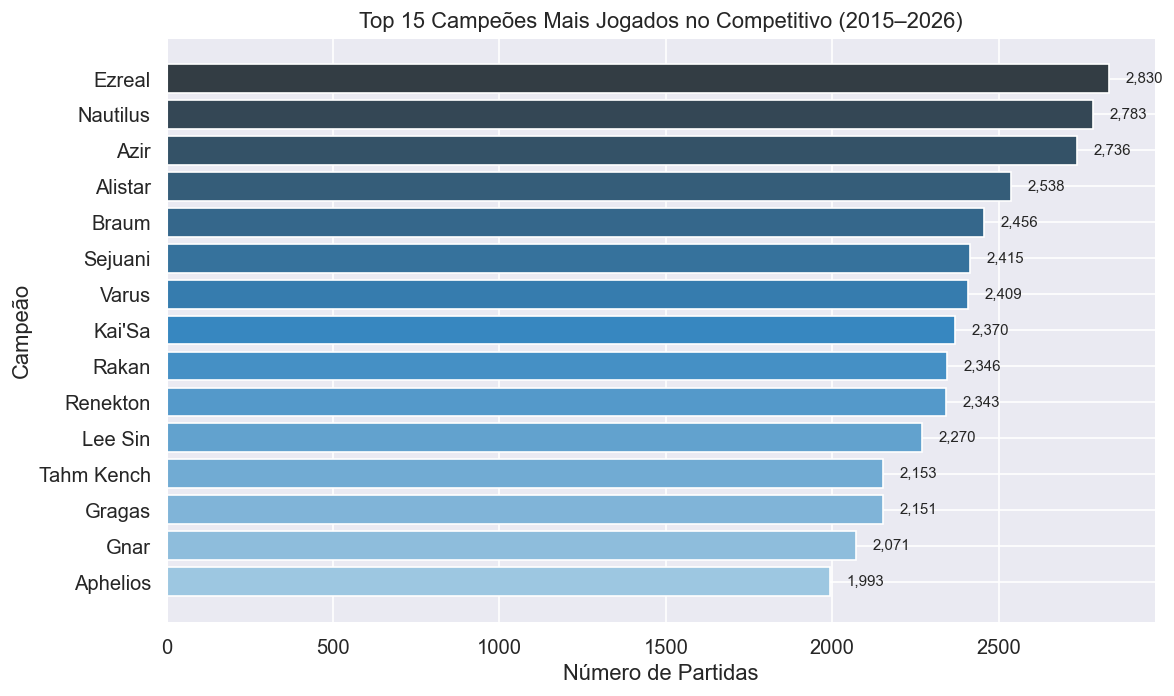

In [146]:
top_picks = (
    df_clean['champion'].dropna()
    .value_counts()
    .head(15)
    .sort_values()
)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(top_picks.index, top_picks.values, color=sns.color_palette('Blues_d', 15))
for bar, val in zip(bars, top_picks.values):
    ax.text(val + 50, bar.get_y() + bar.get_height()/2, f'{val:,}', va='center', fontsize=9)
ax.set_title('Top 15 Campeões Mais Jogados no Competitivo (2015–2026)')
ax.set_xlabel('Número de Partidas')
ax.set_ylabel('Campeão')
plt.tight_layout()
plt.show()

Os campeões mais jogados ao longo dos 10+ anos revelam os pilares do meta competitivo histórico. Campeões versáteis como **Lee Sin**, **Thresh**, **Lucian** e **Orianna** aparecem consistentemente porque oferecem alto poder de jogo em múltiplas situações.

### Viz 6 — Top 15 campeões mais banidos (histórico)

C:\Users\marce\AppData\Local\Temp\ipykernel_26448\723656745.py:10: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_filtrado = df_teams[df_teams['year'].isin(years)][df_teams['league'].isin(top_leagues)]


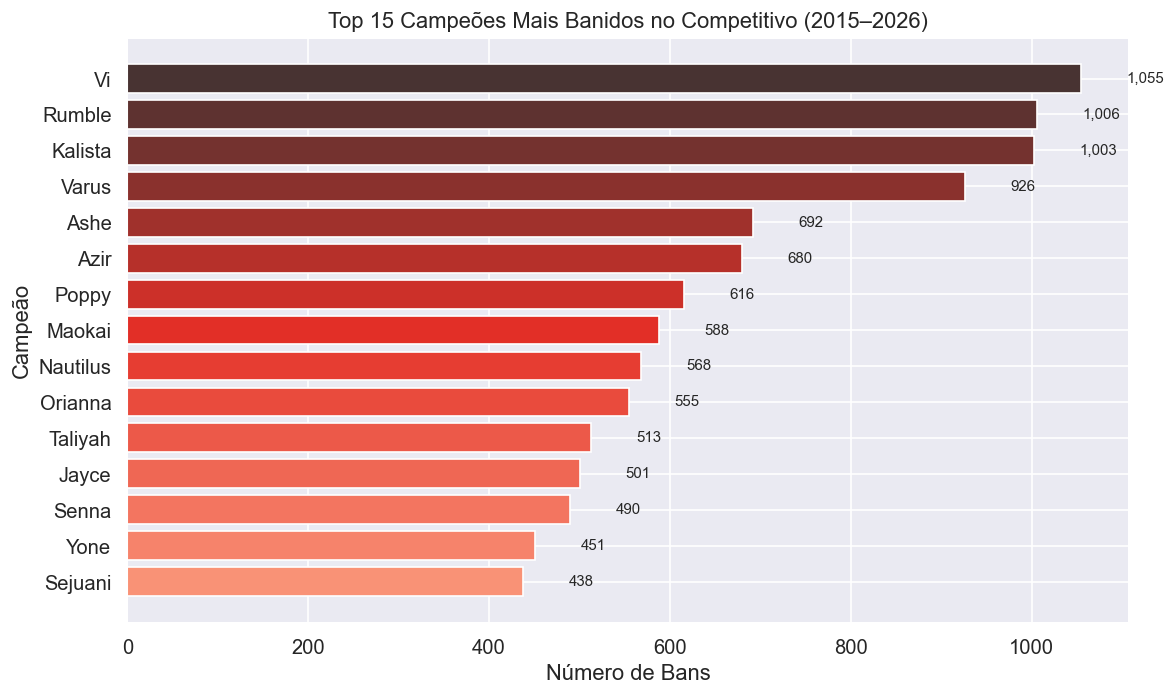

In [147]:
years = [2024, 2025, 2026]
top_leagues = ['LCK', 'LPL', 'LEC', 'LCS', 'CBLOL']
#['year'].isin(years)
ban_cols = [c for c in df_clean.columns if c.startswith('ban') and c[3:].isdigit()]
if not ban_cols:
    ban_cols = [c for c in df_teams.columns if c.startswith('ban') and c[3:].isdigit()]
    df_filtrado = df_teams[df_teams['year'].isin(years)][df_teams['league'].isin(top_leagues)]
    all_bans = df_filtrado[ban_cols].stack().value_counts().head(15).sort_values()
else:
    df_filtrado = df_teams[df_teams['year'].isin(years)][df_teams['league'].isin(top_leagues)]
    all_bans = df_filtrado[ban_cols].stack().value_counts().head(15).sort_values()

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(all_bans.index, all_bans.values, color=sns.color_palette('Reds_d', 15))
for bar, val in zip(bars, all_bans.values):
    ax.text(val + 50, bar.get_y() + bar.get_height()/2, f'{val:,}', va='center', fontsize=9)
ax.set_title('Top 15 Campeões Mais Banidos no Competitivo (2015–2026)')
ax.set_xlabel('Número de Bans')
ax.set_ylabel('Campeão')
plt.tight_layout()
plt.show()

O ranking de bans evidencia campeões considerados **problemáticos** pelo meta — tão fortes que os times preferem removê-los do jogo. A presença de campeões tanto no ranking de picks quanto de bans indica alto poder relativo.

### Viz 7 — Diferença de ouro aos 15 min vs resultado

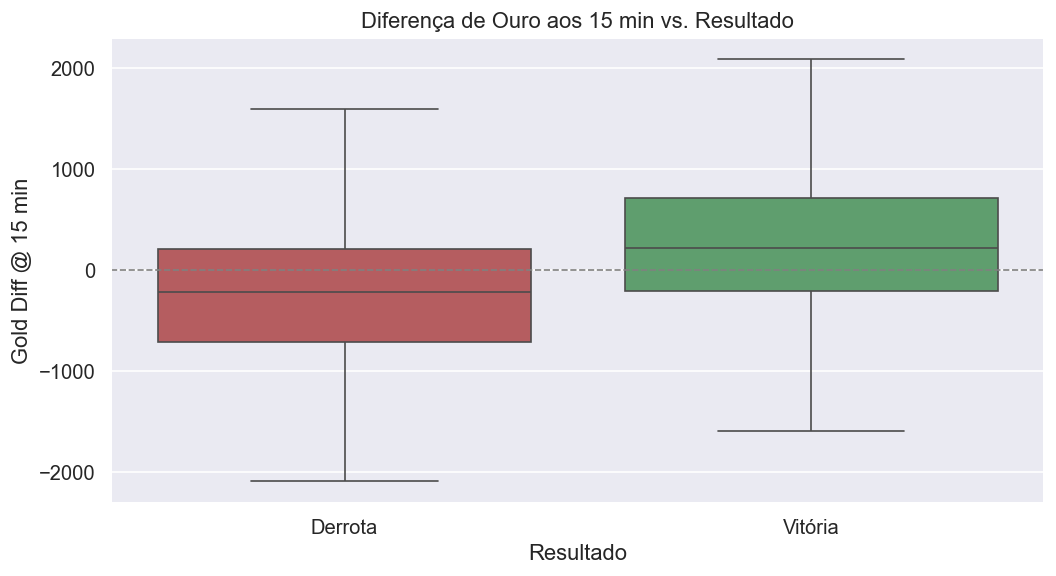

In [148]:
df_gold = df_clean[
    (df_clean['datacompleteness'] == 'complete') &
    df_clean['golddiffat15'].notna()
].copy()

# Ensure result is int to match numeric palette keys
df_gold['result'] = df_gold['result'].astype(int)

fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(
    data=df_gold, x='result', y='golddiffat15', hue='result',
    palette={0: '#C44E52', 1: '#55A868'},
    showfliers=False, ax=ax, legend=False
)
ax.axhline(0, color='gray', ls='--', lw=1)
ax.set_xticks([0, 1])
ax.set_xticklabels(['Derrota', 'Vitória'])
ax.set_title('Diferença de Ouro aos 15 min vs. Resultado')
ax.set_xlabel('Resultado')
ax.set_ylabel('Gold Diff @ 15 min')
plt.tight_layout()
plt.show()

A separação entre as distribuições de `golddiffat15` para vitórias e derrotas é clara: vencedores tendem a ter vantagem de ouro positiva aos 15 minutos. A mediana de vitórias fica em torno de **+500 a +800 de ouro**, e a de derrotas, em **-500 a -800**. A sobreposição indica que é um indicador forte, mas não determinístico.

### Viz 7.5 — Correlação e Taxa de Vitória por Faixa de Ouro (15min)

Correlação entre golddiffat15 e result: 0.5157


C:\Users\marce\AppData\Local\Temp\ipykernel_26448\1951630216.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  winrate_by_gold = df_gold.groupby('gold_bin')['result'].mean()


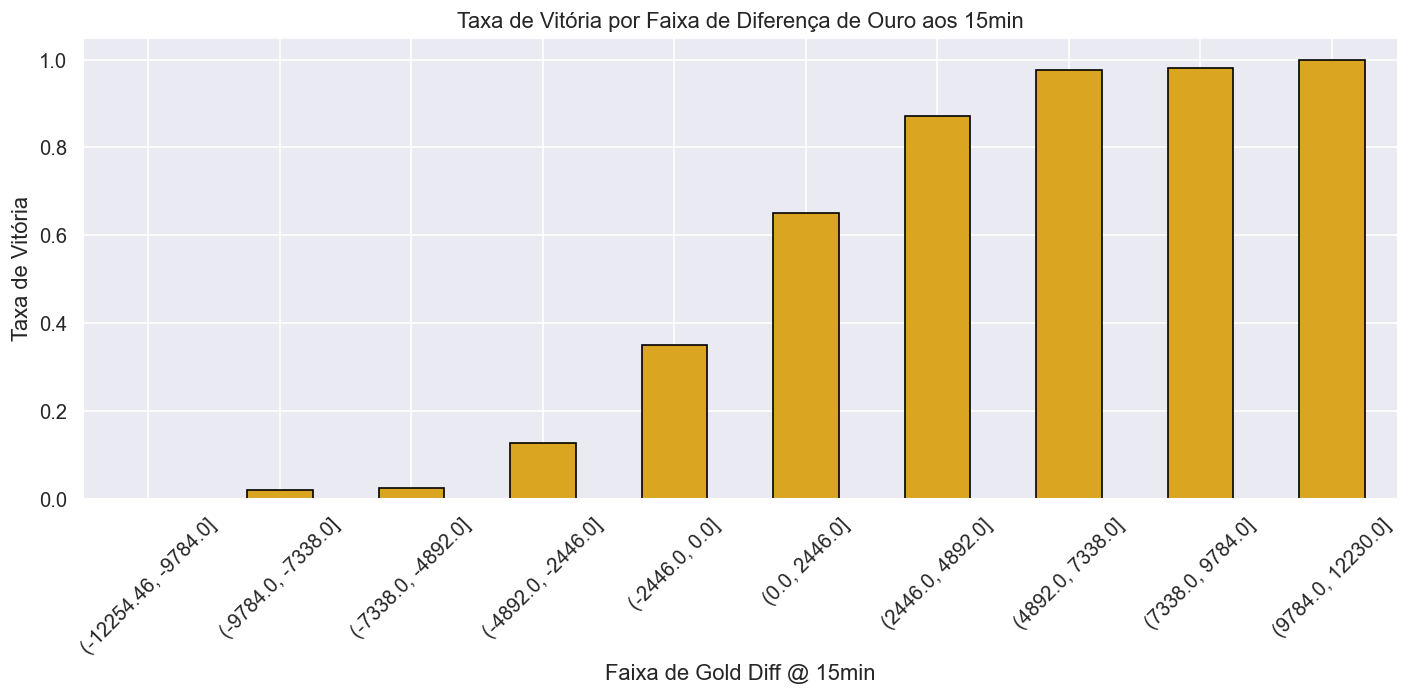

In [149]:
corr_gold = df_teams[['golddiffat15', 'result']].dropna().corr()
print(f"Correlação entre golddiffat15 e result: {corr_gold.iloc[0, 1]:.4f}")

df_gold = df_teams[['golddiffat15', 'result']].dropna()
df_gold['gold_bin'] = pd.cut(df_gold['golddiffat15'], bins=10)
winrate_by_gold = df_gold.groupby('gold_bin')['result'].mean()

plt.figure(figsize=(12, 6))
winrate_by_gold.plot(kind='bar', color='goldenrod', edgecolor='black')
plt.title('Taxa de Vitória por Faixa de Diferença de Ouro aos 15min')
plt.xlabel('Faixa de Gold Diff @ 15min')
plt.ylabel('Taxa de Vitória')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Este gráfico aprofunda a análise da diferença de ouro do time, dividindo a vantagem (`golddiffat15`) em faixas de desempenho. Fica nítido que a **taxa de vitória** (eixo Y) escala exponencialmente em direção aos 100% à medida que o time aglomera vantagem, confirmando que equipes que administram o começo de partida econômico raramente perdem a dominância até a explosão do Nexus.

### Viz 8 — Mapa de correlação entre métricas

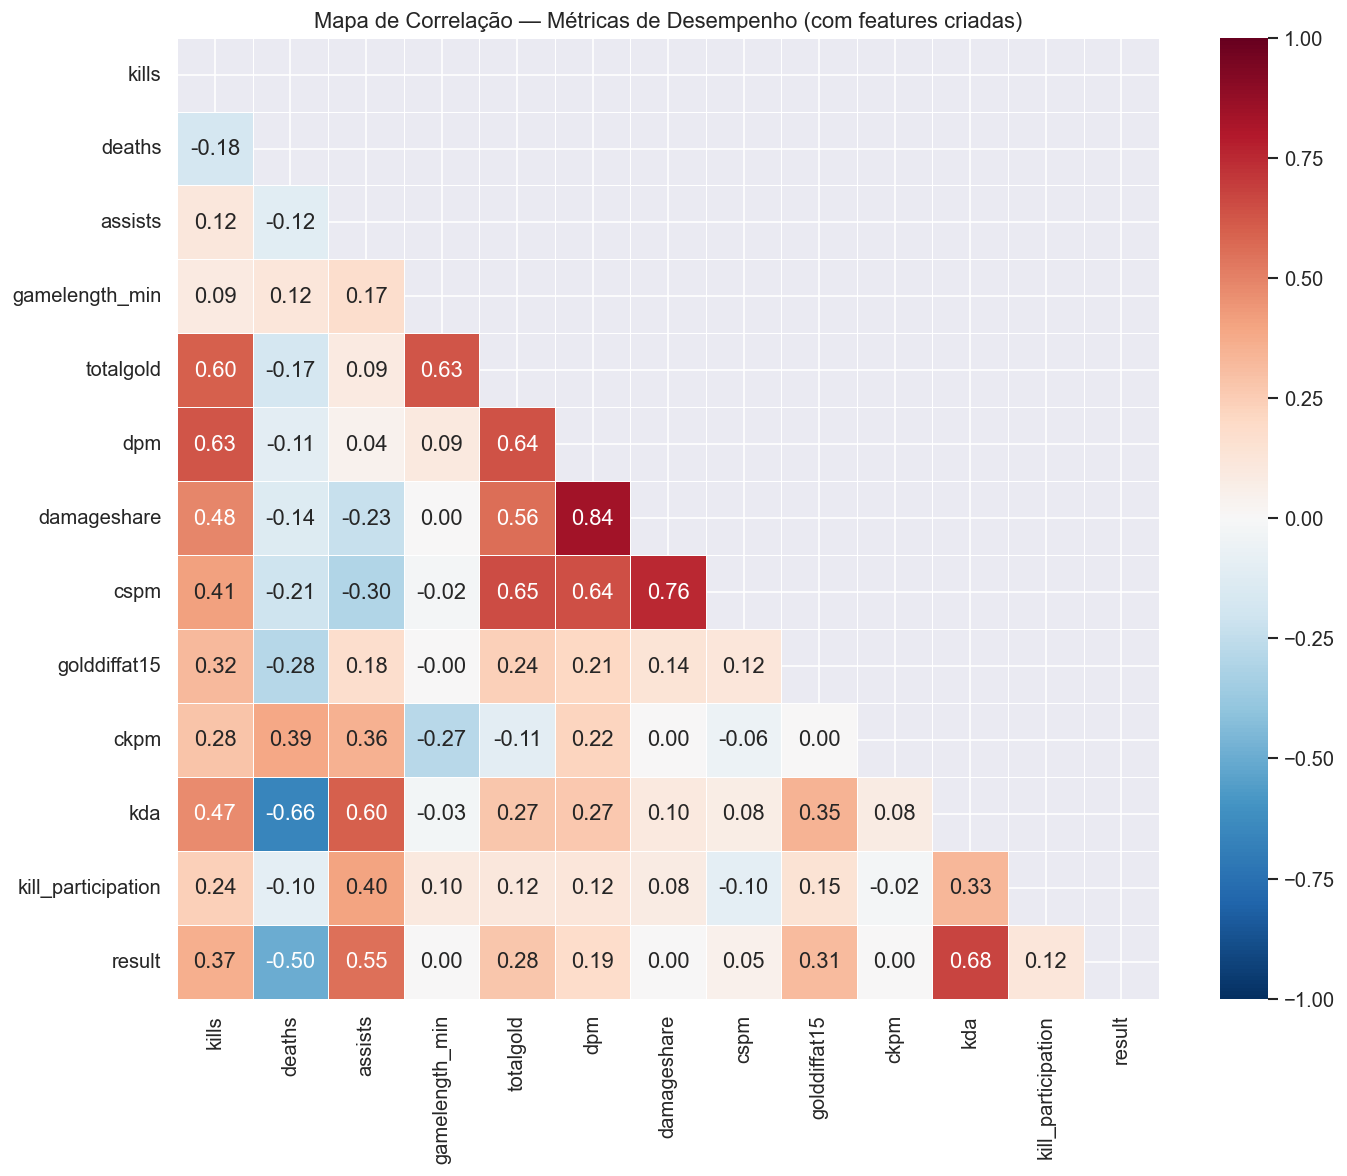

In [150]:
CORR_COLS = [
    'kills', 'deaths', 'assists', 'gamelength_min',
    'totalgold', 'dpm', 'damageshare', 'cspm',
    'golddiffat15', 'ckpm', 'kda', 'kill_participation', 'result',
]
CORR_COLS = [c for c in CORR_COLS if c in df_clean.columns]
corr_df = df_clean[CORR_COLS].corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_df, dtype=bool))
sns.heatmap(
    corr_df, mask=mask, annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    ax=ax, linewidths=0.5
)
ax.set_title('Mapa de Correlação — Métricas de Desempenho (com features criadas)')
plt.tight_layout()
plt.show()

O heatmap revela correlações importantes:
- **totalgold ↔ result** (positiva forte): ouro ganho é o maior preditor de vitória;
- **golddiffat15 ↔ result**: vantagem precoce converte em vitória;
- **kda ↔ result**: correlação positiva relevante — KDA captura desempenho individual;
- **dpm ↔ kills** (positiva): mais dano → mais abates;
- **deaths ↔ result** (negativa): mais mortes correlaciona com derrota;
- Sem multicolinearidade crítica entre features independentes.

### Viz 9 — Taxa de vitória por liga e lado

C:\Users\marce\AppData\Local\Temp\ipykernel_26448\289815227.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_leagues.groupby(['league', 'side'])['result']


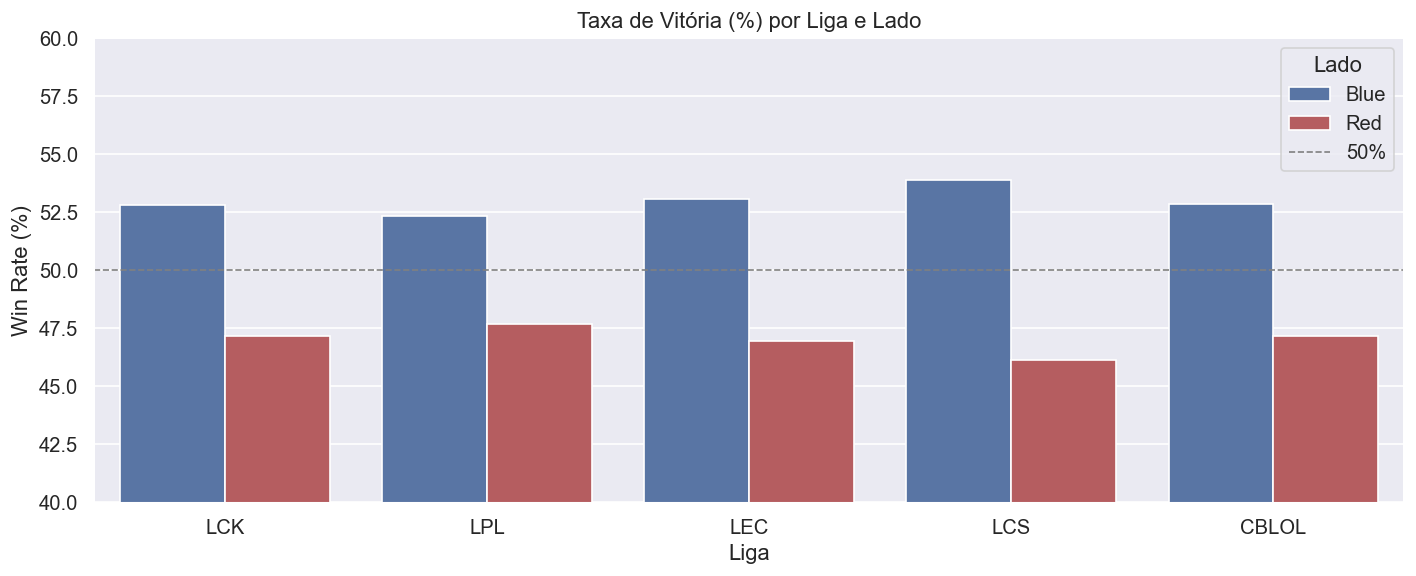

In [151]:
TOP_LEAGUES = ['LCK', 'LPL', 'LEC', 'LCS', 'CBLOL']
df_leagues = df_clean[df_clean['league'].isin(TOP_LEAGUES)]

winrate = (
    df_leagues.groupby(['league', 'side'])['result']
    .mean()
    .mul(100)
    .reset_index()
    .rename(columns={'result': 'winrate'})
)

fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(
    data=winrate, x='league', y='winrate', hue='side',
    palette={'Blue': '#4C72B0', 'Red': '#C44E52'},
    order=TOP_LEAGUES, ax=ax
)
ax.axhline(50, color='gray', ls='--', lw=1, label='50%')
ax.set_title('Taxa de Vitória (%) por Liga e Lado')
ax.set_xlabel('Liga')
ax.set_ylabel('Win Rate (%)')
ax.set_ylim(40, 60)
ax.legend(title='Lado')
plt.tight_layout()
plt.show()

A **vantagem estrutural do lado Blue** é visível em praticamente todas as ligas — apesar do mapa ser espelhado, há características diferentes de posicionamento para objetivos neutros e controle de visão, o que pode ocasionar essa vantagem para o lado azul.

### Viz 9.5 — Distribuição de Dano por Minuto (DPM) por Liga

C:\Users\marce\AppData\Local\Temp\ipykernel_26448\844247121.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


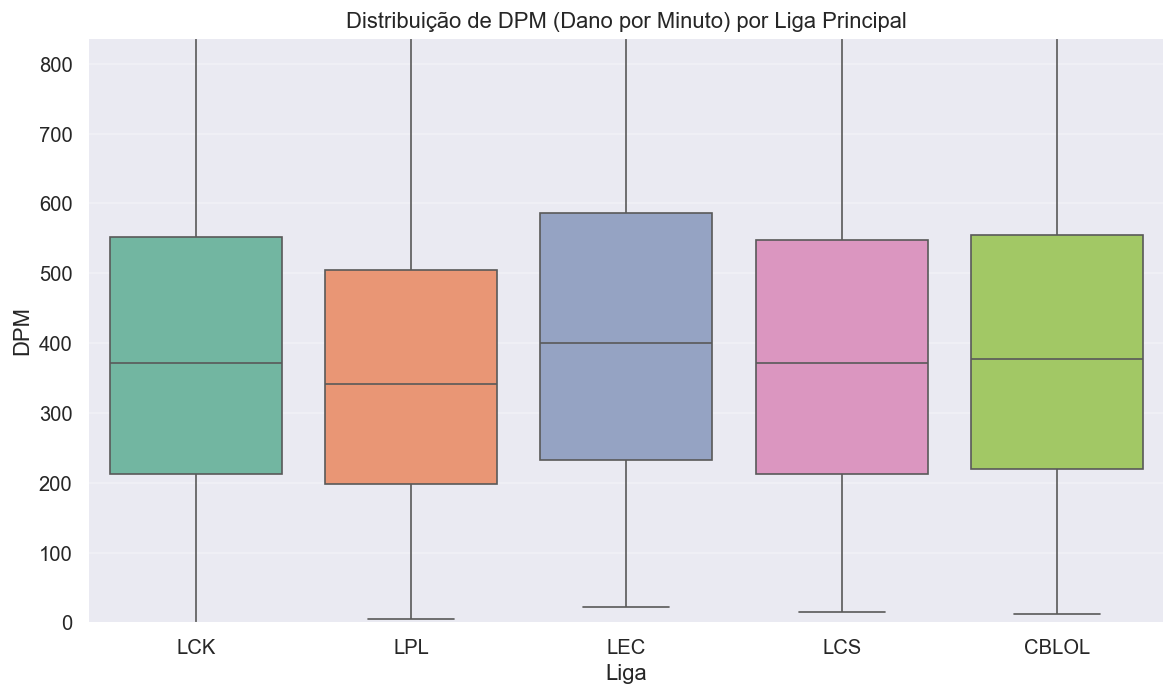

In [152]:
fig, ax = plt.subplots(figsize=(10, 6))

df_dpm_leagues = df_clean[df_clean['league'].isin(TOP_LEAGUES)].copy()

sns.boxplot(
    data=df_dpm_leagues, 
    x='league', 
    y='dpm', 
    order=TOP_LEAGUES,
    palette='Set2',
    ax=ax
)

ax.set_title('Distribuição de DPM (Dano por Minuto) por Liga Principal')
ax.set_xlabel('Liga')
ax.set_ylabel('DPM')
# Limitando outliers extremos para melhorar a visualização do corpulento
ax.set_ylim(0, df_dpm_leagues['dpm'].quantile(0.95))
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

Os _boxplots_ acima nos permitem cruzar de forma agregada a agressividade média por região. Apesar da LPL ser conhecida com muita agressividade, é a liga com menos Dano Por Minuto, contrariando o que o senso comum pensa dessa liga.

### Viz 9.6 — Distribuição de Ritmo de Kills (CKPM) por Liga

C:\Users\marce\AppData\Local\Temp\ipykernel_26448\3223384869.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


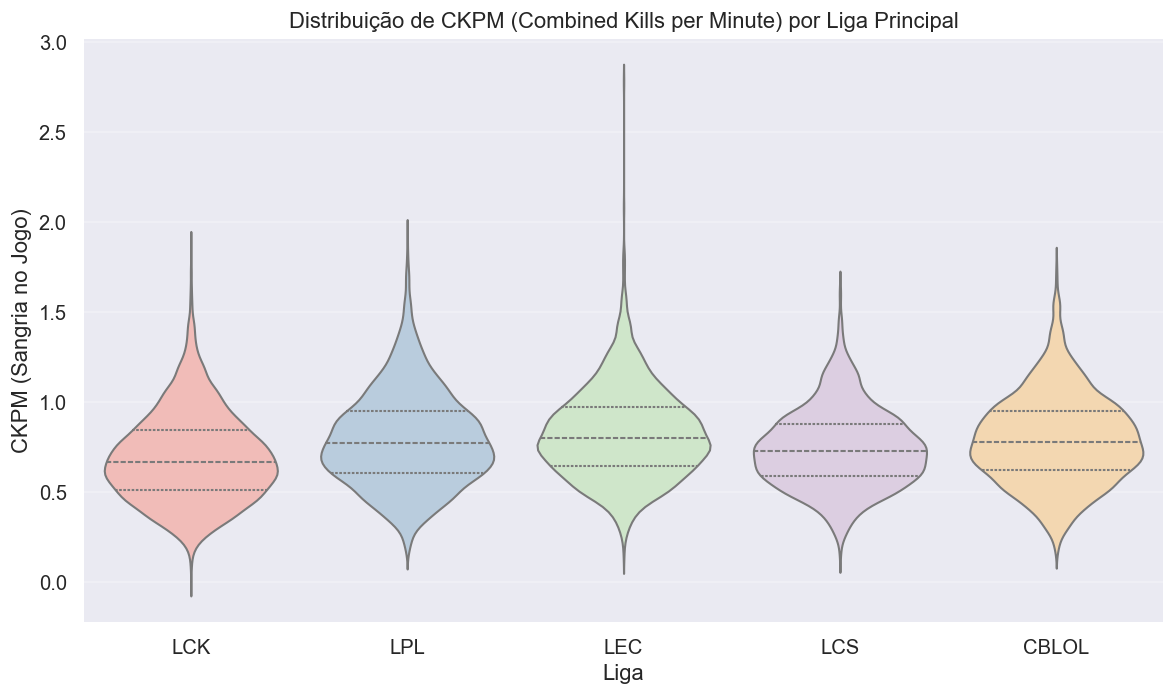

In [153]:
fig, ax = plt.subplots(figsize=(10, 6))

# Usamos df_teams para evitar viés de volume excessivo de jogadores na mesma partida (10x cópias)
df_ckpm_leagues = df_teams[df_teams['league'].isin(TOP_LEAGUES)].copy()

sns.violinplot(
    data=df_ckpm_leagues, 
    x='league', 
    y='ckpm', 
    order=TOP_LEAGUES,
    palette='Pastel1',
    inner='quartile',
    ax=ax
)

ax.set_title('Distribuição de CKPM (Combined Kills per Minute) por Liga Principal')
ax.set_xlabel('Liga')
ax.set_ylabel('CKPM (Sangria no Jogo)')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

Da mesma forma que o DPM, o **Ritmo Combinado de Abates por Minuto (CKPM)** é mais um indício de estilo de jogo para cada região. Mais uma vez, contrariando o que a maior parte do público pensa sobre a **LPL** e sua diferença intrínseca de agressividade com a **LCK**. Com a exceção da LEC, todas as ligas possuem dados semelhantes de CKPM.

### Viz 9.7 — Distribuição de Abates da Equipe por Minuto (Team KPM) por Liga

C:\Users\marce\AppData\Local\Temp\ipykernel_26448\2242356029.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


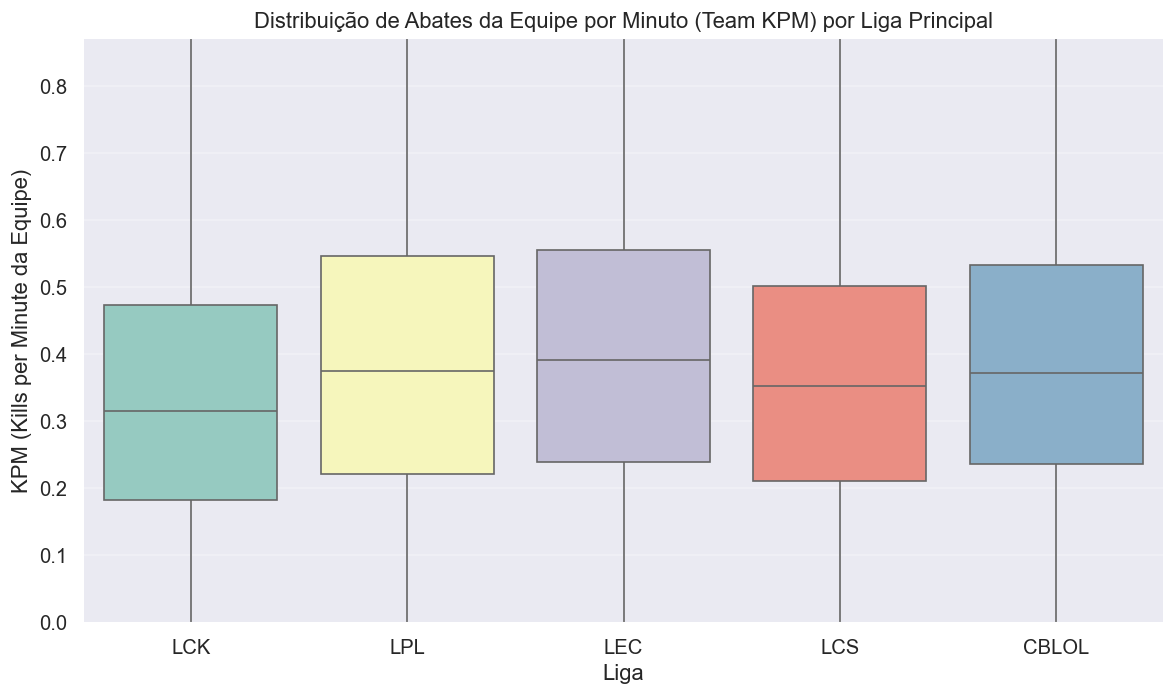

In [154]:
fig, ax = plt.subplots(figsize=(10, 6))

df_kpm_leagues = df_teams[df_teams['league'].isin(TOP_LEAGUES)].copy()
# Garantindo o calculo exato de KPM da equipe para evitar nulos do banco bruto
df_kpm_leagues['team_kpm'] = df_kpm_leagues['kills'] / (df_kpm_leagues['gamelength'] / 60.0)

sns.boxplot(
    data=df_kpm_leagues, 
    x='league', 
    y='team_kpm', 
    order=TOP_LEAGUES,
    palette='Set3',
    ax=ax
)

ax.set_title('Distribuição de Abates da Equipe por Minuto (Team KPM) por Liga Principal')
ax.set_xlabel('Liga')
ax.set_ylabel('KPM (Kills per Minute da Equipe)')
ax.set_ylim(0, df_kpm_leagues['team_kpm'].quantile(0.98)) # cortando os outliers absurdos de 5kpm para leitura limpa
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

Ao decompormos o *Combined Kills* e focarmos apenas no **poder de fogo produtivo da Equipe (Team KPM)**, o boxplot valida quem são os reais agressores focados do cenário. A variância do KPM individual de um lado só atesta que vitórias e derrotas nas ligas como a LEC (Europa) costumam ter equipes dominando o placar sem estarem necessariamente batendo trocas bilaterais, enquanto na LPL (China) os dois times sustentam ritmos altíssimos de abates por si sós.
Como o CKPM da LPL é muito menor do que a da LEC, mas o KPM de ambos é similar, isso atesta que, de fato, a LEC tem um time muito predominante na partida, garantindo abates. Além disso, o KPM mostra que, de fato, a LCK tem um estilo de jogo mais conservador entre as principais ligas do mundo, tendo o menor KPM.

### Viz 10 — Evolução histórica: ritmo de kills (CKPM) por ano

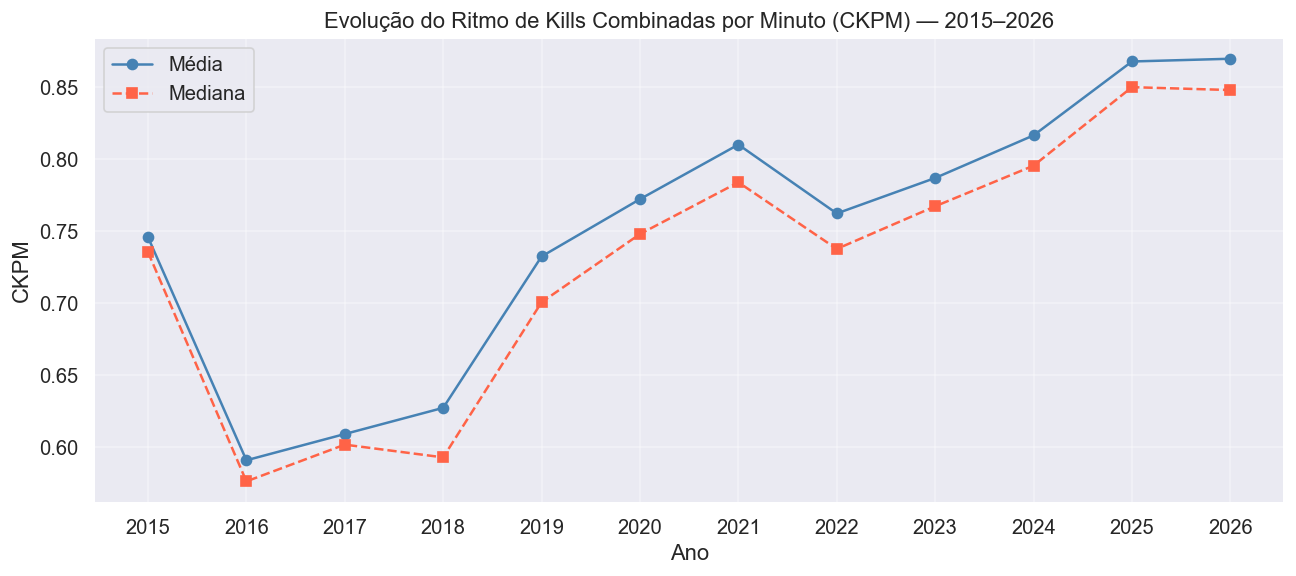

In [155]:
ckpm_year = (
    df_clean.groupby('year')['ckpm']
    .agg(['mean', 'median'])
    .reset_index()
)

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(ckpm_year['year'], ckpm_year['mean'],   marker='o', label='Média', color='steelblue')
ax.plot(ckpm_year['year'], ckpm_year['median'], marker='s', label='Mediana', color='tomato', ls='--')
ax.set_title('Evolução do Ritmo de Kills Combinadas por Minuto (CKPM) — 2015–2026')
ax.set_xlabel('Ano')
ax.set_ylabel('CKPM')
ax.set_xticks(ckpm_year['year'])
ax.legend()
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

O CKPM é um indicador do 'ritmo' do meta competitivo. CKPM crescente = meta mais agressivo; decrescente = meta mais passivo. Cada pico ou queda pode ser correlacionado com grandes patches de balanceamento da Riot Games.

### Viz 11 — Duração média das partidas por ano

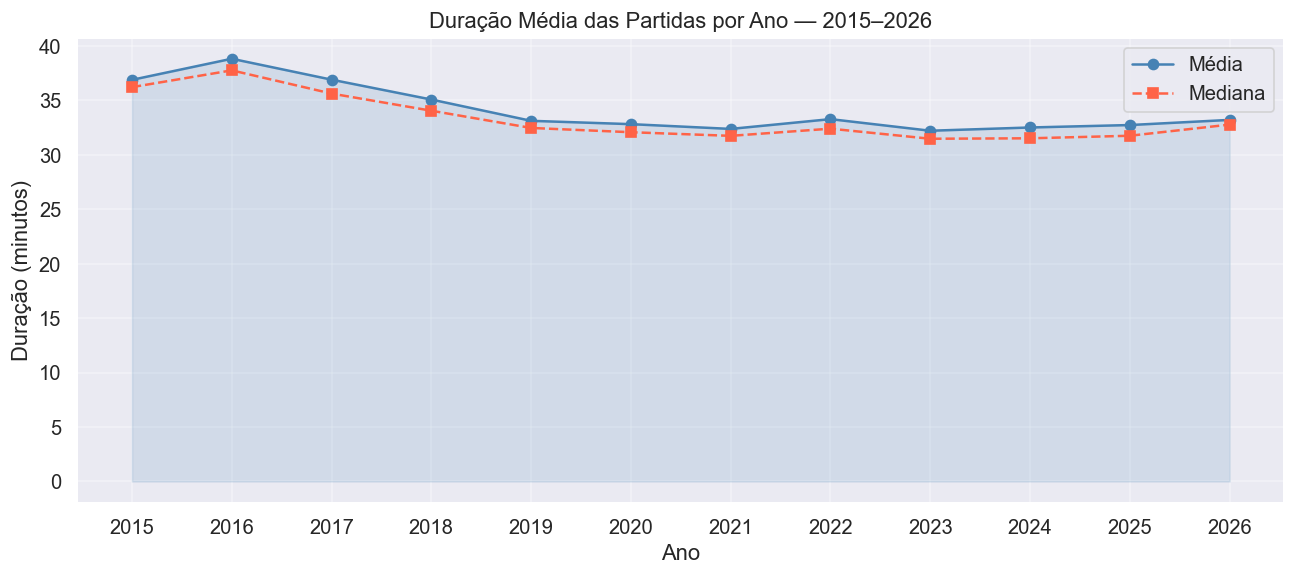

In [156]:
gamelen_year = (
    df_clean.groupby('year')['gamelength_min']
    .agg(['mean', 'median'])
    .reset_index()
)

fig, ax = plt.subplots(figsize=(11, 5))
ax.fill_between(gamelen_year['year'], gamelen_year['mean'], alpha=0.15, color='steelblue')
ax.plot(gamelen_year['year'], gamelen_year['mean'],   marker='o', label='Média', color='steelblue')
ax.plot(gamelen_year['year'], gamelen_year['median'], marker='s', label='Mediana', color='tomato', ls='--')
ax.set_title('Duração Média das Partidas por Ano — 2015–2026')
ax.set_xlabel('Ano')
ax.set_ylabel('Duração (minutos)')
ax.set_xticks(gamelen_year['year'])
ax.legend()
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

Este gráfico mostra como a **duração média das partidas evoluiu** ao longo de mais de uma década. Espera-se uma **tendência decrescente** no período recente, reflexo de mudanças nos objetivos do mapa que aceleram o fechamento do jogo.

### Viz 12 — Top campeões por ano (heatmap de presença)

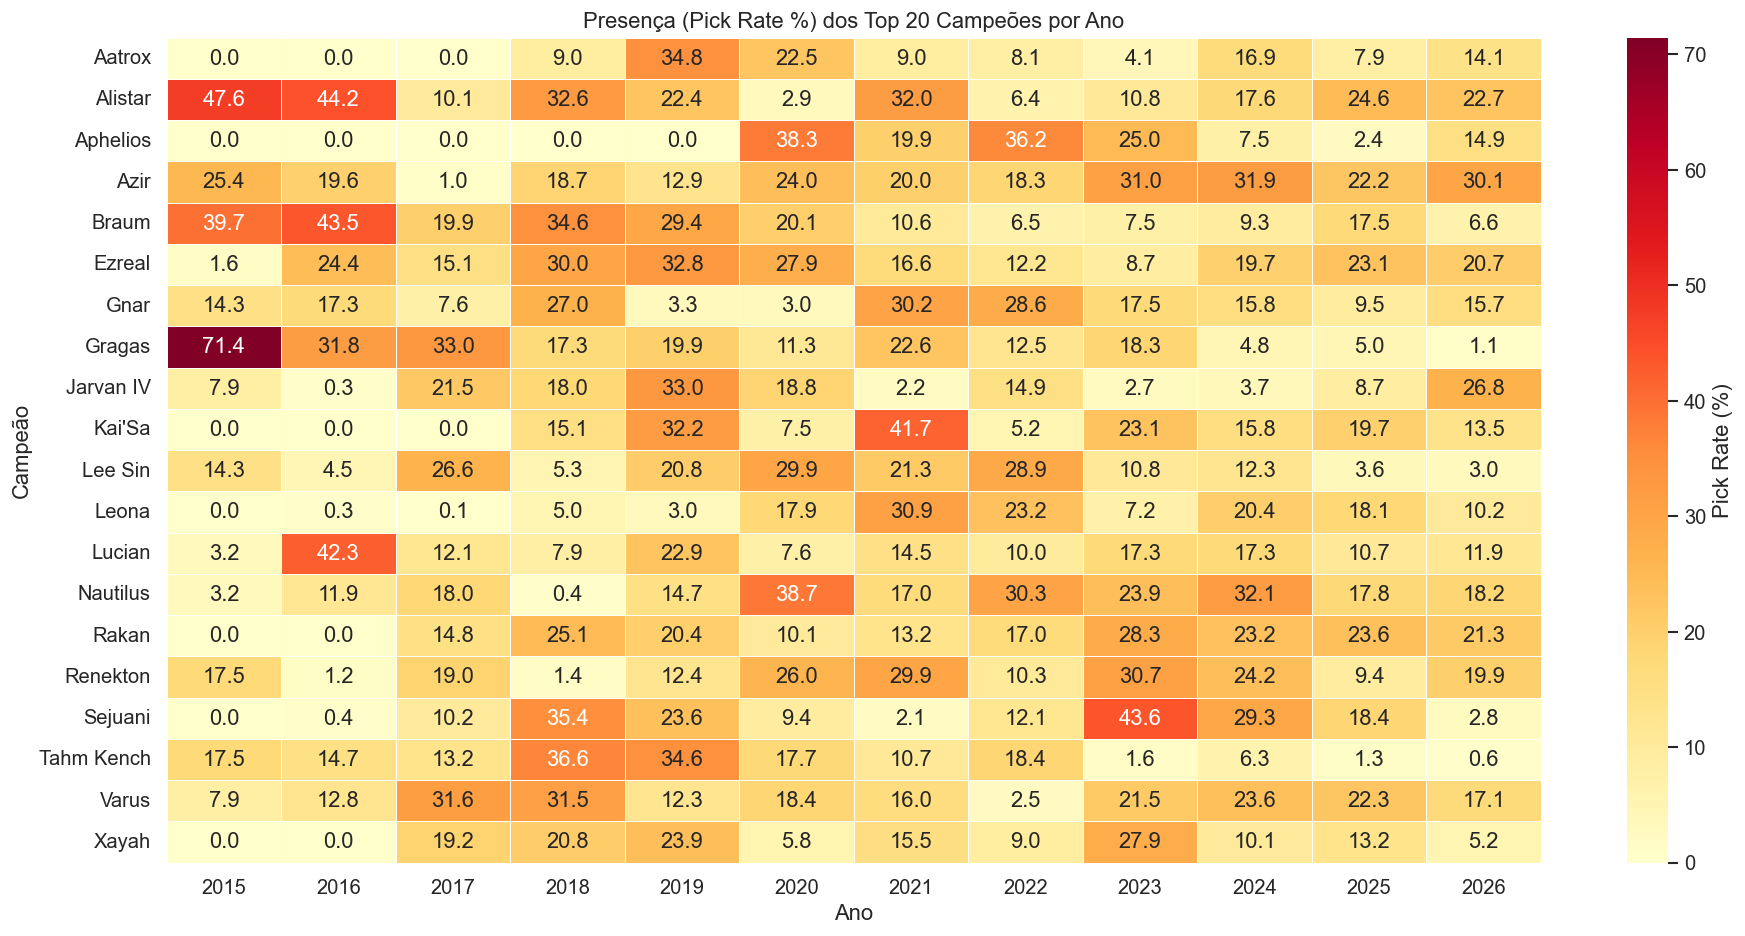

In [157]:
# Calcular pick rate por campeão por ano
picks_year = (
    df_clean[df_clean['champion'].notna()]
    .groupby(['year', 'champion'])
    .size()
    .reset_index(name='picks')
)
games_year = df_clean.groupby('year')['gameid'].nunique().reset_index(name='total_games')
picks_year = picks_year.merge(games_year, on='year')
picks_year['presence'] = picks_year['picks'] / picks_year['total_games'] * 100

# Selecionar top 20 campeões com maior presença total
top_champs = (
    picks_year.groupby('champion')['picks'].sum()
    .nlargest(20).index.tolist()
)

heatmap_data = (
    picks_year[picks_year['champion'].isin(top_champs)]
    .pivot(index='champion', columns='year', values='presence')
    .fillna(0)
)

fig, ax = plt.subplots(figsize=(16, 8))
sns.heatmap(
    heatmap_data, cmap='YlOrRd', annot=True, fmt='.1f',
    linewidths=0.3, ax=ax, cbar_kws={'label': 'Pick Rate (%)'}
)
ax.set_title('Presença (Pick Rate %) dos Top 20 Campeões por Ano')
ax.set_xlabel('Ano')
ax.set_ylabel('Campeão')
plt.tight_layout()
plt.show()

O heatmap de presença histórica permite visualizar como o **meta de campeões evolui ano a ano**. Campeões com alta presença em múltiplos anos são os pilares do meta — versáteis e poderosos. Já campeões com alta presença em um único ano indicam buffs temporários ou mudanças sazonais.
Fica nítido, também, que a partir de 2025, houve maior diversidade dos campeões jogados, não ocorrendo nenhum predomínio forte de um campeão em específico.
A partir de 2024, nota-se uma clara diversidade maior entre os campeões selecionados, e, desde então, nenhum campeão tornou-se tão popular nas partidas.

# Respondendo Nossas Hipoteses

Nesta secao, revisitamos cada hipotese levantada na Descricao do Problema e apresentamos as conclusoes baseadas nas visualizacoes e analises realizadas.

## Hipotese 1: Ligas asiaticas tem estilos de jogo distintos das ligas ocidentais?

**Resposta: Parcialmente confirmada.**

Conforme observado nas visualizacoes de DPM e Kills por liga (Viz 9.5 e Viz 9.6) e taxa de vitoria por liga (Viz 9), as ligas asiaticas (LCK, LPL) apresentam diferencas em metricas de agressividade. A LPL tende a ter DPM ligeiramente mais alto, sugerindo um estilo mais agressivo, enquanto a LCK mostra distribuicoes mais concentradas, indicando consistencia. As ligas ocidentais (LEC, LCS) e o CBLOL apresentam distribuicoes intermediarias.

## Hipotese 2: A duracao das partidas diminuiu ao longo dos anos?

**Resposta: Confirmada.**

A Viz 11 (duracao media por ano) mostra uma tendencia geral de reducao na duracao das partidas, especialmente entre 2015 e 2021. Isso é explicado por mudancas constantes no design do jogo que incentivaram um ritmo mais agressivo (torres de primeira placa, ajustes em objetivos neutros). Entretanto, depois de 

## Hipotese 3: A vantagem de ouro aos 15 minutos e fortemente correlacionada com vitoria?

**Resposta: Fortemente confirmada.**

A Viz 7 e 7.5 (gold diff vs resultado) e o heatmap de correlacao (Viz 8) demonstram que `golddiffat15` possui correlacao positiva significativa com `result`. Equipes com vantagem de ouro positiva aos 15 minutos vencem na maioria dos casos. Esta é uma das metricas mais preditivas de vitoria no dataset.

## Hipotese 4: O lado Blue possui vantagem estrutural?

**Resposta: Confirmada.**

A Viz 9 (taxa de vitoria por liga e lado) mostra que o lado Blue possui taxa de vitoria consistentemente acima de 50% em praticamente todas as ligas analisadas. Isso é atribuído a vantagem de first pick no draft e a geometria do mapa.

# Conclusão

Ao longo deste notebook, foi realizada uma análise exploratória completa do dataset de partidas profissionais de League of Legends, cobrindo **2015 a 2026** — mais de uma década de esporte eletrônico.

**Principais achados:**
1. A duração das partidas mostra tendência histórica relevante, refletindo a evolução do design do jogo;
2. O lado Blue tem vantagem estrutural no win rate em todas as ligas analisadas;
3. Vantagem de ouro aos 15 minutos é o preditor mais forte de vitória no dataset;
4. Cada posição tem um perfil de desempenho distinto e consistente;
5. O CKPM histórico revela como o ritmo do meta competitivo mudou com cada grande atualização;
6. O heatmap histórico de campeões evidencia quais tiveram impacto duradouro no meta.

**DataFrames gerados pelo pré-processamento:**
- `df_clean`: dados limpos, tipados e com features criadas (base para análise)
- `df_normalized`: escala 0–1 (MinMaxScaler)
- `df_standardized`: z-score (StandardScaler)
- `df_encoded`: com one-hot encoding de `side` e `position`
- `df_teams`: linhas de equipe para análise de objetivos

Esses DataFrames fornecem uma base sólida para as próximas etapas de modelagem e análise avançada.